# Cycle-level 피처 + 오토인코더 (v2)

기존 `train_pump.ipynb`(틱 단위 14피처)를 대체하는 새 파이프라인.

**기존 대비 바뀐 점**
- 블록 리셋 기준: Wagon+BuildUp 혼합 -> **Pump_BuildUp 단독**
- 단위: 틱 1개 = 1행 -> **사이클(BuildUp on~off) 1회 = 1행**
- `BuildUp==0` 구간을 통째로 버리지 않음 (PreBuildUp_PT/FT, Decay_Slope 계산에 필요)
- 물리 기반 피처 추가: 전류추정치 `I = dP*FT/Hz`, `dP/Q` 비율, 감쇠 기울기(PT/FT), 기저변동성
- SHOT 신호와 무관하게 발생한 압력/유량 하락(= 유출 의심) 카운트
- 제외 규칙: `AL_Line_Bit==1` 구간, 매일 23:50~06:45에 시작하는 사이클
- Train/Valid/Test를 **겹치지 않는 기간**으로 분리

In [1]:
import os
import sys

ROOT_DIR = os.path.dirname(os.getcwd())  # parkkt/ 의 부모 = 저장소 루트
sys.path.insert(0, ROOT_DIR)
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import joblib

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import (extract_cycle_features, PUMP_MAP,
                                     DAILY_EXCLUDE_START, DAILY_EXCLUDE_END)
from Cycle_AE import CycleAutoencoder

ENV_PATH = os.path.join(ROOT_DIR, ".env")
MODEL_SAVE_DIR = os.path.join(os.getcwd(), "models_v2")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

## 1. 설정

`PUMP_ID`만 바꾸면 헤드/로봇/SEL슬롯이 자동으로 따라간다 (기존 노트북은 셋을 손으로 따로 적어야 해서 어긋날 위험이 있었음).

In [2]:
PUMP_ID = "P1"
info = PUMP_MAP[PUMP_ID]
HEAD, ROBOT, SLOT = info["head"], info["robot"], info["slot"]
print(f"{PUMP_ID} -> 헤드 {HEAD}, 로봇 {ROBOT}, 사출신호 Shot_Injection_{HEAD}_P{SLOT}")

# 겹치지 않는 Train / Valid / Test 기간
# 주의: 일요일(9/13, 9/20)은 생산이 없다. Valid가 일요일에 걸리면 사이클이
# 1/3 수준으로 줄어 검증이 왜곡되므로, Valid는 생산이 도는 평일 구간으로 잡는다.
TRAIN_START, TRAIN_END = "2026-09-10T07:00:00Z", "2026-09-18T07:00:00Z"   # 8일
VALID_START, VALID_END = "2026-09-18T07:00:00Z", "2026-09-19T07:00:00Z"   # 1일 (금~토, 생산일)
TEST_START,  TEST_END  = "2026-09-20T19:00:00Z", "2026-09-23T18:00:00Z"   # 6일 고정 (now() 로 두면 실행할 때마다 범위가 달라져 비교가 어긋난다)                  # 월요일 04:00 KST ~ (일요일 제외)

TARGET_TAGS = [
    f"Pump_BuildUp_{PUMP_ID}",
    f"g_s_SV_{PUMP_ID}",
    f"Scale_Out___FT_{PUMP_ID}",
    f"Scale_Out___PT_{PUMP_ID}",
    f"Ana_Out_{PUMP_ID}",
    f"TK_Temp_PV_{info['tank']}",
    f"Hz_Out_{PUMP_ID}",
    f"Shot_Injection_{HEAD}_P{SLOT}",   # 이 펌프가 실제로 사출하는 순간
    f"{ROBOT}_Robot_Num",
    "AL_Line_Bit",
] + [f"{HEAD}_FOAMING_SHOT{k}" for k in range(1, 7)]

print(f"태그 {len(TARGET_TAGS)}개")

P1 -> 헤드 HD1, 로봇 RB1, 사출신호 Shot_Injection_HD1_P1
태그 16개


## 2. 데이터 추출 & 사이클 피처 생성

In [3]:
extractor = LogExtractor(env_path=ENV_PATH)

def build(start, end, label):
    raw = extractor.get_data(start_time=start, end_time=end, target_tags=TARGET_TAGS)
    cyc, _ = extract_cycle_features(raw, PUMP_ID)
    n_excl = int(cyc["Excluded"].sum())
    print(f"[{label}] raw {len(raw):,}행 -> 사이클 {len(cyc):,}개 (제외 대상 {n_excl}개)")
    return cyc

train_cyc = build(TRAIN_START, TRAIN_END, "Train")
valid_cyc = build(VALID_START, VALID_END, "Valid")
test_cyc  = build(TEST_START,  TEST_END,  "Test")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-18T07:00:00+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39428행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35983행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37083행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38257행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

35685행
📦 [Chunk] 2026-09-22T18:50:00Z ~ 2026-09-23T00:50:00Z ... 

36156행
📦 [Chunk] 2026-09-23T00:50:00Z ~ 2026-09-23T02:01:42Z ... 

7720행


✅ 통합 완료 — 343758행 × 17컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.


[Test] raw 343,758행 -> 사이클 6,989개 (제외 대상 156개)


## 3. 제외 규칙 적용 & 피처 정리

`AL_Line_Bit==1`이 낀 사이클, 23:50~06:45에 시작한 사이클을 버린다. **Train/Valid에서만** 버리고, Test는 이상탐지 대상이므로 남겨서 비교한다.

In [4]:
FEATURE_COLS = [
    "N_Ticks",
    "SV_mean", "FT_mean", "FT_max", "FT_std", "PT_mean", "PT_max", "PT_std",
    "Ana_Out_mean", "Temp_mean",
    "Prev_SV", "Prev_SV_Diff",
    "PreBuildUp_PT", "PreBuildUp_FT", "PT_Jump_From_Pre", "FT_Jump_From_Pre",
    "Instant_FT_Error_Rate_mean", "Instant_FT_Error_Rate_max", "Cum_FT_Error",
    "RampUp_Time_Sec", "DeltaP_over_Q", "Current_Proxy_I",
    "Steady_Std_PT", "Steady_Std_FT",
    "Ramp_Negative_Slope_Count",
    "Unexplained_PT_Dip_Count", "Unexplained_PT_Dip_Max",
    "Unexplained_FT_Dip_Count", "Unexplained_FT_Dip_Max",
    "Decay_Slope_PT", "Decay_Slope_FT",
]
print(f"모델 입력 피처 {len(FEATURE_COLS)}개")

def clean(cyc, drop_excluded=True):
    out = cyc.copy()
    if drop_excluded:
        out = out[~out["Excluded"]]

    # Prev_SV==0 은 추출 구간의 첫 사이클(직전 사이클이 없음)에서만 나온다.
    # (SV가 0인 사이클은 실제로 존재하지 않으므로 다른 경우로 0이 될 수 없다.)
    # Prev_SV_Diff가 통째로 SV값이 되어버려 가짜 이상으로 잡히므로 버린다.
    n_cold = int((out["Prev_SV"] == 0).sum())
    if n_cold:
        out = out[out["Prev_SV"] != 0]
        print(f"  Prev_SV==0(구간 첫 사이클) {n_cold}개 제외")

    before = len(out)
    out = out.dropna(subset=FEATURE_COLS)
    if before != len(out):
        print(f"  결측으로 {before - len(out)}개 사이클 제외")
    return out

train_clean = clean(train_cyc)
valid_clean = clean(valid_cyc)
test_clean  = clean(test_cyc, drop_excluded=False)

print(f"Train {len(train_clean):,} / Valid {len(valid_clean):,} / Test {len(test_clean):,}")

모델 입력 피처 31개
  Prev_SV==0(구간 첫 사이클) 1개 제외
  결측으로 185개 사이클 제외
  Prev_SV==0(구간 첫 사이클) 1개 제외
  결측으로 19개 사이클 제외
  Prev_SV==0(구간 첫 사이클) 1개 제외
  결측으로 7개 사이클 제외
Train 20,524 / Valid 2,934 / Test 6,981


## 4. 스케일링 (Train에만 fit)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_clean[FEATURE_COLS])
X_valid = scaler.transform(valid_clean[FEATURE_COLS])
X_test  = scaler.transform(test_clean[FEATURE_COLS])

joblib.dump(scaler, os.path.join(MODEL_SAVE_DIR, f"scaler_cycle_{PUMP_ID}.pkl"))

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train)),
                          batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(torch.FloatTensor(X_valid), torch.FloatTensor(X_valid)),
                          batch_size=64, shuffle=False)
print(X_train.shape, X_valid.shape, X_test.shape)

(20524, 31) (2934, 31) (6981, 31)


## 5. 오토인코더 학습 (Early Stopping)

In [6]:
torch.manual_seed(42)
model = CycleAutoencoder(input_dim=len(FEATURE_COLS))
criterion = nn.MSELoss()

# 학습 안정화: lr 0.002 에서는 중간에 Loss가 되레 올라가며(epoch 20 -> 40에서 0.164 -> 0.196)
# 실행마다 수렴값이 크게 흔들렸다. lr을 낮추고, 정체되면 자동으로 더 줄이도록 스케줄러를 건다.
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

EPOCHS, PATIENCE = 400, 40
best_val, best_epoch, wait = float("inf"), 0, 0
model_path = os.path.join(MODEL_SAVE_DIR, f"autoencoder_cycle_{PUMP_ID}.pth")
hist = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tr += loss.item()
    tr /= len(train_loader)

    model.eval()
    va = 0.0
    with torch.no_grad():
        for xb, yb in valid_loader:
            va += criterion(model(xb), yb).item()
    va /= len(valid_loader)
    scheduler.step(va)
    hist.append((epoch, tr, va, optimizer.param_groups[0]["lr"]))

    if va < best_val - 1e-5:
        best_val, best_epoch, wait = va, epoch, 0
        torch.save(model.state_dict(), model_path)
    else:
        wait += 1

    if epoch % 20 == 0 or epoch == 1:
        star = "  *best*" if best_epoch == epoch else ""
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:03d} | Train {tr:.4f} | Valid {va:.4f} | lr {lr_now:.1e}{star}")

    if wait >= PATIENCE:
        print(f"\nEarly stopping (epoch {epoch}, best={best_epoch})")
        break

print(f"\n최종 best Valid Loss: {best_val:.4f} (epoch {best_epoch})")
model.load_state_dict(torch.load(model_path, weights_only=True))

Epoch 001 | Train 0.6847 | Valid 0.4434 | lr 5.0e-04  *best*


Epoch 020 | Train 0.1091 | Valid 0.1090 | lr 5.0e-04  *best*


Epoch 040 | Train 0.0957 | Valid 0.0969 | lr 5.0e-04  *best*


Epoch 060 | Train 0.0886 | Valid 0.0906 | lr 5.0e-04


Epoch 080 | Train 0.0847 | Valid 0.0861 | lr 5.0e-04


...

Epoch 160 | Train 0.0791 | Valid 0.0822 | lr 3.1e-05


Epoch 180 | Train 0.0789 | Valid 0.0823 | lr 1.6e-05


Epoch 200 | Train 0.0788 | Valid 0.0824 | lr 3.9e-06



Early stopping (epoch 214, best=174)

최종 best Valid Loss: 0.0819 (epoch 174)


<All keys matched successfully>

## 6. 재구성오차 & 임계치

임계치는 하드코딩이 아니라 **Train(정상) 재구성오차의 99 퍼센타일**로 잡는다.

In [7]:
def recon_error(X):
    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X)
        out = model(t)
        per_feat = (t - out) ** 2
        return per_feat.mean(dim=1).numpy(), per_feat.numpy()

train_err, _ = recon_error(X_train)
valid_err, _ = recon_error(X_valid)
test_err, test_per_feat = recon_error(X_test)

THRESHOLD = float(np.percentile(train_err, 99))
print(f"임계치 (Train 99퍼센타일): {THRESHOLD:.4f}")
for name, err in [("Train", train_err), ("Valid", valid_err), ("Test", test_err)]:
    over = (err > THRESHOLD)
    print(f"{name:6s} | 평균 {err.mean():.4f} | 중앙값 {np.median(err):.4f} | "
          f"95% {np.percentile(err,95):.4f} | 최대 {err.max():.4f} | "
          f"임계치 초과 {over.sum():,}건 ({over.mean()*100:.2f}%)")

임계치 (Train 99퍼센타일): 0.3167
Train  | 평균 0.0789 | 중앙값 0.0616 | 95% 0.1866 | 최대 4.5118 | 임계치 초과 206건 (1.00%)
Valid  | 평균 0.0820 | 중앙값 0.0636 | 95% 0.1932 | 최대 1.1659 | 임계치 초과 47건 (1.60%)
Test   | 평균 0.0919 | 중앙값 0.0694 | 95% 0.2127 | 최대 4.8100 | 임계치 초과 142건 (2.03%)


## 7. Test 구간 이상 탐지 + 범인 색출 (피처별 기여도)

In [8]:
res = test_clean.copy()
res["Recon_Error"] = test_err
res["Is_Anomaly"] = res["Recon_Error"] > THRESHOLD

anomalies = res[res["Is_Anomaly"]].sort_values("Recon_Error", ascending=False)
print(f"Test 사이클 {len(res):,}개 중 이상 {len(anomalies):,}건 "
      f"({len(anomalies)/max(len(res),1)*100:.2f}%)\n")

for rank, (idx, row) in enumerate(anomalies.head(10).iterrows(), 1):
    pos = res.index.get_loc(idx)
    contrib = pd.Series(test_per_feat[pos], index=FEATURE_COLS)
    contrib = (contrib / contrib.sum() * 100).sort_values(ascending=False)
    flags = []
    if row["Excluded_Alarm"]:
        flags.append("AL_Line_Bit=1")
    if row["Excluded_DailyWindow"]:
        flags.append(f"{DAILY_EXCLUDE_START}~{DAILY_EXCLUDE_END}")
    if row["Cold_Start"]:
        flags.append("콜드스타트")
    flag_txt = (" | " + ", ".join(flags)) if flags else ""
    print(f"[#{rank}] {row['Start_Time']} | 오차 {row['Recon_Error']:.3f}{flag_txt}")
    for f, v in contrib.head(3).items():
        print(f"      - {f}: {v:.1f}%  (값 {row[f]:.3f})")

Test 사이클 6,981개 중 이상 142건 (2.03%)

[#1] 2026-09-22 07:13:31.848542 | 오차 4.810
      - Unexplained_FT_Dip_Max: 46.9%  (값 0.182)
      - Unexplained_FT_Dip_Count: 26.7%  (값 1.000)
      - PreBuildUp_FT: 8.9%  (값 1285.000)
[#2] 2026-09-21 10:18:51.454193 | 오차 2.667
      - Unexplained_FT_Dip_Max: 31.8%  (값 0.046)
      - Unexplained_FT_Dip_Count: 18.3%  (값 2.000)
      - FT_Jump_From_Pre: 14.2%  (값 15.000)
[#3] 2026-09-21 12:12:06.097914 | 오차 2.577
      - Unexplained_FT_Dip_Max: 28.5%  (값 0.134)
      - Unexplained_FT_Dip_Count: 22.3%  (값 1.000)
      - FT_Jump_From_Pre: 11.9%  (값 0.000)
[#4] 2026-09-23 07:04:07.024733 | 오차 2.323
      - N_Ticks: 29.0%  (값 12.000)
      - Instant_FT_Error_Rate_mean: 12.6%  (값 14.716)
      - Steady_Std_FT: 10.7%  (값 469.788)
[#5] 2026-09-21 22:42:08.446741 | 오차 1.862
      - Unexplained_FT_Dip_Max: 22.9%  (값 0.072)
      - FT_Jump_From_Pre: 17.9%  (값 15.000)
      - Unexplained_FT_Dip_Count: 10.1%  (값 2.000)
[#6] 2026-09-21 09:45:16.903823 | 오차 1.670
   

## 8. 시각화

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


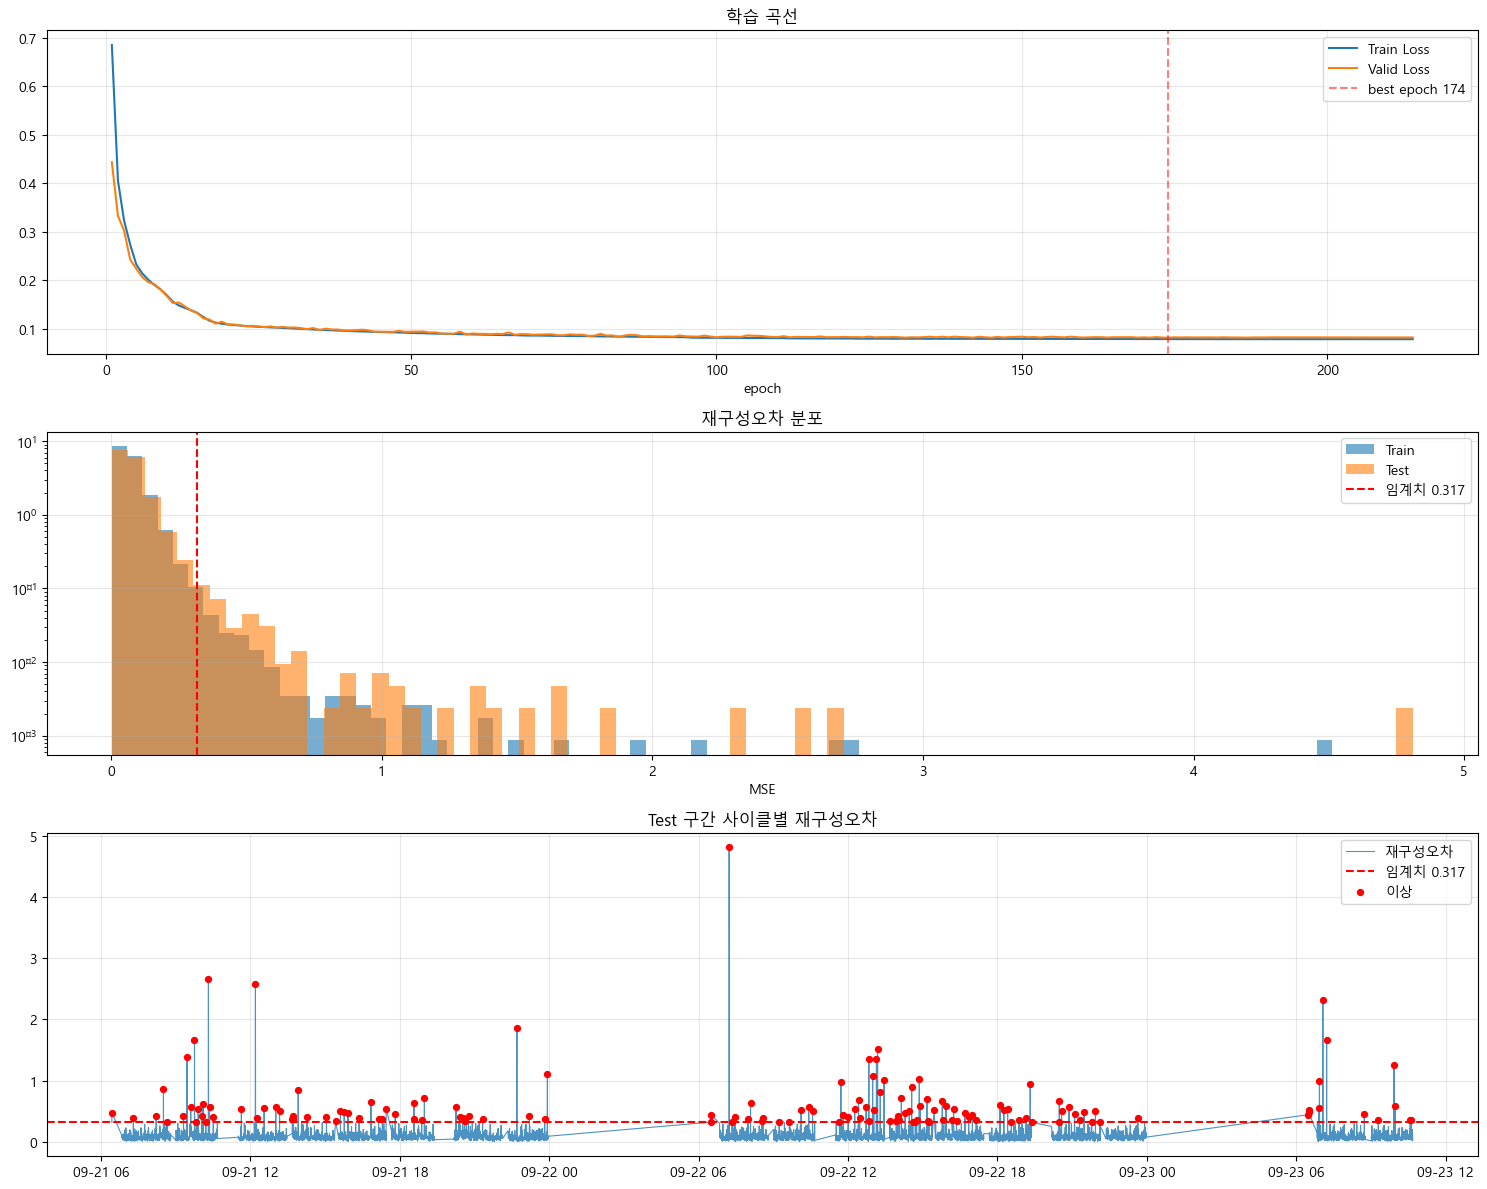

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# (1) 학습 곡선
h = pd.DataFrame(hist, columns=["epoch", "train", "valid", "lr"])
axes[0].plot(h["epoch"], h["train"], label="Train Loss")
axes[0].plot(h["epoch"], h["valid"], label="Valid Loss")
axes[0].axvline(best_epoch, color="red", ls="--", alpha=0.5, label=f"best epoch {best_epoch}")
axes[0].set_title("학습 곡선")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=.3)

# (2) 재구성오차 분포
axes[1].hist(train_err, bins=80, alpha=.6, label="Train", density=True)
axes[1].hist(test_err, bins=80, alpha=.6, label="Test", density=True)
axes[1].axvline(THRESHOLD, color="red", ls="--", label=f"임계치 {THRESHOLD:.3f}")
axes[1].set_title("재구성오차 분포")
axes[1].set_xlabel("MSE")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(alpha=.3)

# (3) Test 구간 시계열
axes[2].plot(res["Start_Time"], res["Recon_Error"], lw=.8, alpha=.8, label="재구성오차")
axes[2].axhline(THRESHOLD, color="red", ls="--", label=f"임계치 {THRESHOLD:.3f}")
an = res[res["Is_Anomaly"]]
axes[2].scatter(an["Start_Time"], an["Recon_Error"], color="red", s=18, zorder=5, label="이상")
axes[2].set_title("Test 구간 사이클별 재구성오차")
axes[2].legend()
axes[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 9. 일별 추세 (서서히 진행되는 열화 모니터링)

Day/Week 계층은 별도 AE가 아니라, **Cycle-level AE 재구성오차를 날짜별로 집계한 추세**로 본다.

                mean       std  n_cycles       p95      EWMA
Date                                                        
2026-09-10  0.073830  0.068199      1348  0.169811  0.073830
2026-09-11  0.099222  0.068037      2885  0.214683  0.090758
2026-09-12  0.078325  0.069637      3178  0.174120  0.083653
2026-09-14  0.078512  0.101107      2822  0.176979  0.080911
2026-09-15  0.076004  0.109908      2901  0.182311  0.078379
2026-09-16  0.072395  0.073865      2914  0.184133  0.075339
2026-09-17  0.073464  0.068709      2960  0.174836  0.074394
2026-09-18  0.077416  0.083804      2861  0.195326  0.075911
2026-09-19  0.084340  0.066292      1589  0.196191  0.080134
2026-09-21  0.090244  0.111465      2961  0.205001  0.085194
2026-09-22  0.093139  0.123454      3330  0.219104  0.089169
2026-09-23  0.093375  0.137328       690  0.209841  0.091272


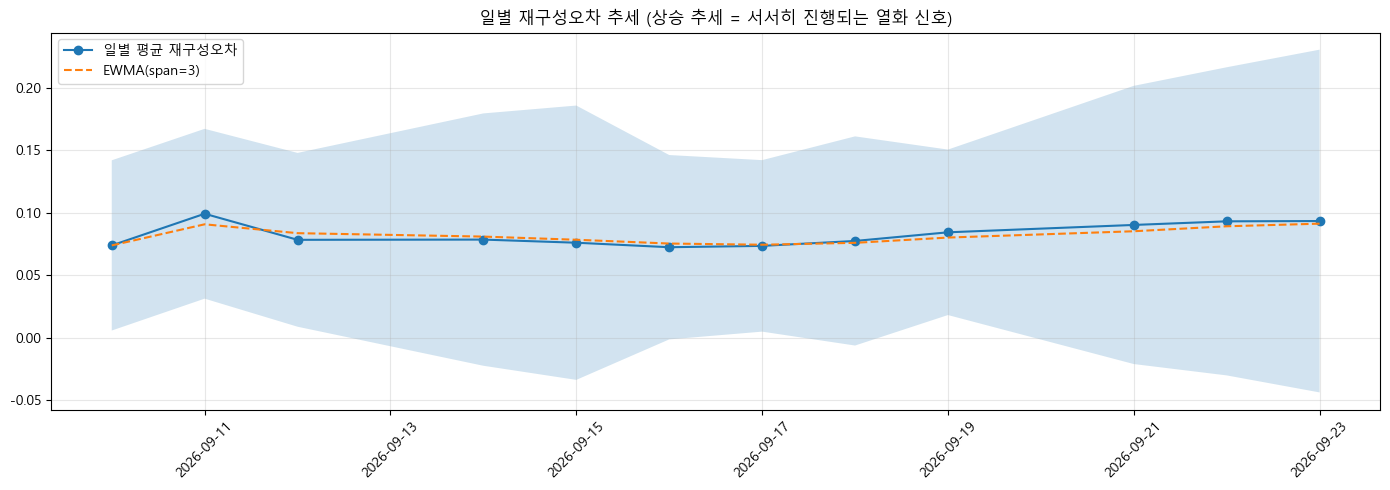

In [10]:
all_res = []
for name, cyc, X in [("Train", train_clean, X_train),
                     ("Valid", valid_clean, X_valid),
                     ("Test", test_clean, X_test)]:
    err, _ = recon_error(X)
    tmp = cyc[["Start_Time"]].copy()
    tmp["Recon_Error"] = err
    tmp["Split"] = name
    all_res.append(tmp)
all_res = pd.concat(all_res).sort_values("Start_Time")
all_res["Date"] = all_res["Start_Time"].dt.date

daily = all_res.groupby("Date")["Recon_Error"].agg(
    mean="mean", std="std", n_cycles="count", p95=lambda s: np.percentile(s, 95))
daily["EWMA"] = daily["mean"].ewm(span=3).mean()
print(daily.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily["mean"], marker="o", label="일별 평균 재구성오차")
ax.plot(daily.index, daily["EWMA"], ls="--", label="EWMA(span=3)")
ax.fill_between(daily.index, daily["mean"] - daily["std"], daily["mean"] + daily["std"], alpha=.2)
ax.set_title("일별 재구성오차 추세 (상승 추세 = 서서히 진행되는 열화 신호)")
ax.legend()
ax.grid(alpha=.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. 피처별 재구성 난이도

표준화(평균0·표준편차1) 후이므로, **어떤 피처도 못 맞히면 그 피처의 오차는 1.0**이 된다(=평균만 찍는 수준). 0에 가까울수록 모델이 그 피처를 잘 설명한다는 뜻이고, 1에 가까운 피처는 모델이 규칙을 못 찾은 것 = 그 피처는 사실상 노이즈이거나 다른 피처로 설명이 안 되는 독립 신호라는 뜻이다.

피처별 평균 재구성오차 (1.0 = 전혀 못 맞힘, 0 = 완벽히 복원)
SV_mean                       0.011273
Ana_Out_mean                  0.011403
FT_max                        0.012145
Ramp_Negative_Slope_Count     0.013156
Prev_SV_Diff                  0.014292
Instant_FT_Error_Rate_max     0.015596
FT_mean                       0.018001
PT_mean                       0.023962
PT_max                        0.027888
Current_Proxy_I               0.030775
Unexplained_FT_Dip_Max        0.031678
Unexplained_FT_Dip_Count      0.034895
Prev_SV                       0.035946
FT_std                        0.038132
Cum_FT_Error                  0.042410
Unexplained_PT_Dip_Count      0.044246
Unexplained_PT_Dip_Max        0.045557
PreBuildUp_FT                 0.049597
Instant_FT_Error_Rate_mean    0.076109
Decay_Slope_PT                0.079859
PT_std                        0.081189
FT_Jump_From_Pre              0.084899
Steady_Std_FT                 0.108605
RampUp_Time_Sec               0.116270
N_Ticks                

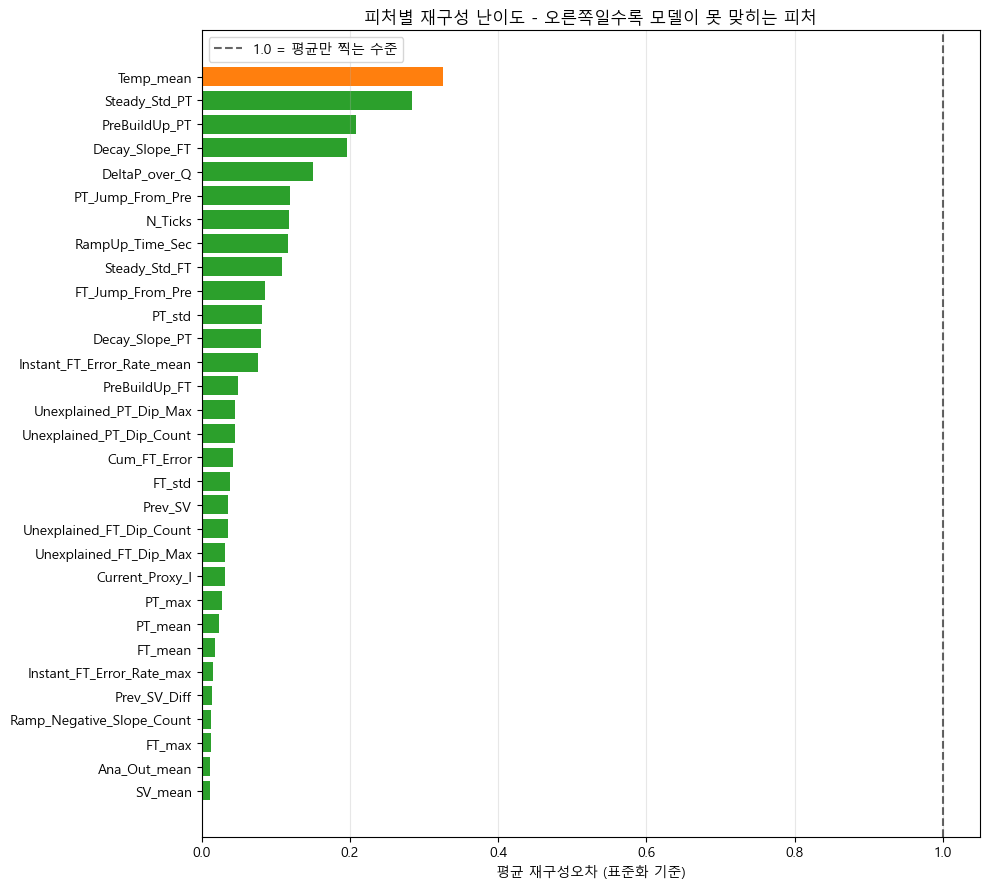

In [11]:
_, train_pf = recon_error(X_train)
per_feat_err = pd.Series(train_pf.mean(axis=0), index=FEATURE_COLS).sort_values()

print("피처별 평균 재구성오차 (1.0 = 전혀 못 맞힘, 0 = 완벽히 복원)")
print(per_feat_err.to_string())

fig, ax = plt.subplots(figsize=(10, 9))
colors = ["tab:green" if v < 0.3 else "tab:orange" if v < 0.7 else "tab:red"
          for v in per_feat_err.values]
ax.barh(per_feat_err.index, per_feat_err.values, color=colors)
ax.axvline(1.0, color="black", ls="--", alpha=.6, label="1.0 = 평균만 찍는 수준")
ax.set_xlabel("평균 재구성오차 (표준화 기준)")
ax.set_title("피처별 재구성 난이도 - 오른쪽일수록 모델이 못 맞히는 피처")
ax.legend()
ax.grid(axis="x", alpha=.3)
plt.tight_layout()
plt.show()